
Bisection Method Iterations Table:

 Iter        a        b        c      f(a)     f(b)      f(c)    |b-a|
    1 1.000000 2.000000 1.500000 -2.000000 4.000000 -0.125000 1.000000
    2 1.500000 2.000000 1.750000 -0.125000 4.000000  1.609375 0.500000
    3 1.500000 1.750000 1.625000 -0.125000 1.609375  0.666016 0.250000
    4 1.500000 1.625000 1.562500 -0.125000 0.666016  0.252197 0.125000
    5 1.500000 1.562500 1.531250 -0.125000 0.252197  0.059113 0.062500
    6 1.500000 1.531250 1.515625 -0.125000 0.059113 -0.034054 0.031250
    7 1.515625 1.531250 1.523438 -0.034054 0.059113  0.012250 0.015625
    8 1.515625 1.523438 1.519531 -0.034054 0.012250 -0.010971 0.007812
    9 1.519531 1.523438 1.521484 -0.010971 0.012250  0.000622 0.003906
   10 1.519531 1.521484 1.520508 -0.010971 0.000622 -0.005179 0.001953
   11 1.520508 1.521484 1.520996 -0.005179 0.000622 -0.002279 0.000977
   12 1.520996 1.521484 1.521240 -0.002279 0.000622 -0.000829 0.000488
   13 1.521240 1.521484 1.521362 -0.0008

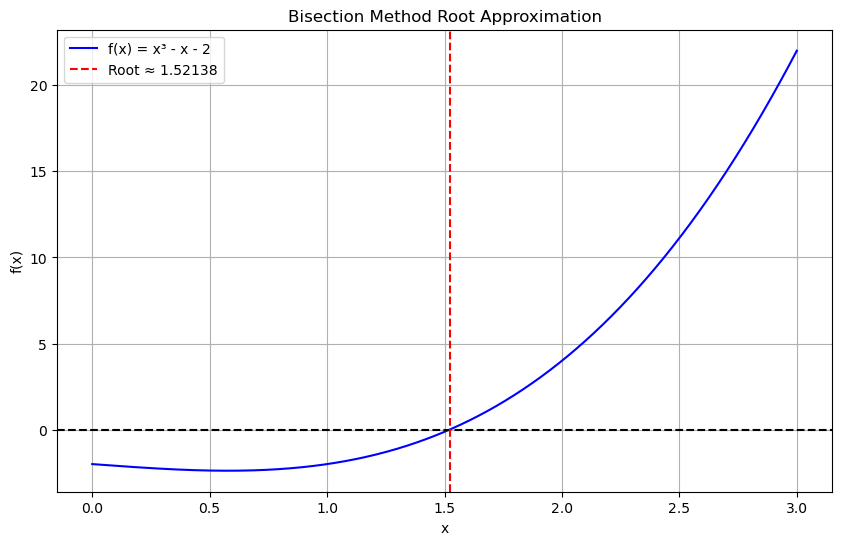

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the function
def f(x):
    return x**3 - x - 2  # Example function

# Bisection Method
def bisection(a, b, tol=1e-5, max_iter=100):
    if f(a) * f(b) >= 0:
        print("Bisection method fails. f(a) and f(b) must have opposite signs.")
        return None
    
    iterations = []
    
    for i in range(max_iter):
        c = (a + b) / 2.0
        fc = f(c)
        iterations.append([i+1, a, b, c, f(a), f(b), fc, abs(b-a)])
        
        if abs(fc) < tol or abs(b - a) < tol:
            break
        
        if f(a) * fc < 0:
            b = c
        else:
            a = c
            
    return c, iterations

# Inputs
a = 1
b = 2
root, table = bisection(a, b)

# Tabular format using pandas
df = pd.DataFrame(table, columns=["Iter", "a", "b", "c", "f(a)", "f(b)", "f(c)", "|b-a|"])
print("\nBisection Method Iterations Table:\n")
print(df.to_string(index=False))

# Graphical visualization
x_vals = np.linspace(a-1, b+1, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10,6))
plt.plot(x_vals, y_vals, label='f(x) = x³ - x - 2', color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(root, color='red', linestyle='--', label=f'Root ≈ {root:.5f}')
plt.title("Bisection Method Root Approximation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()
